In [16]:
import tensorflow as tf
import numpy as np
import pandas as pd
from keras.src.layers import BatchNormalization
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [17]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)

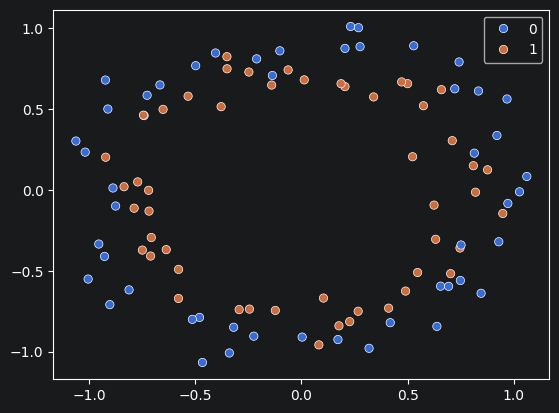

In [18]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [20]:
model = Sequential()
model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/home/opera/miniconda3/envs/tf-gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [22]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    verbose=0
)

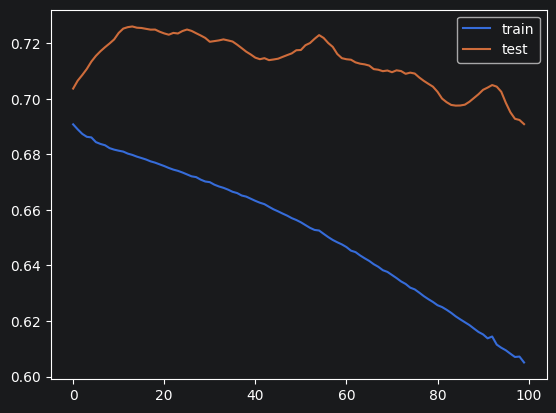

In [23]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


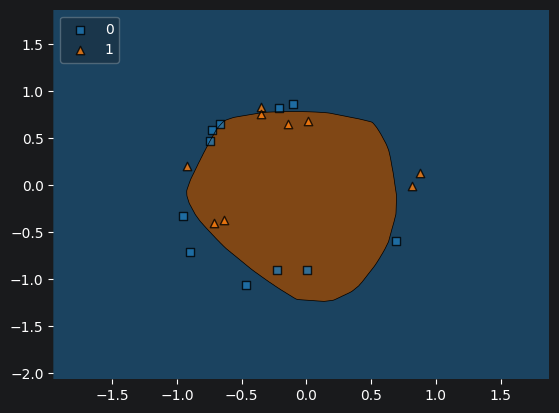

In [24]:
plot_decision_regions(X_test, y_test.ravel(), clf=model, legend=2)
plt.show()

Early Stopping  Applied here

In [25]:
model = Sequential()

model.add(Dense(48, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(32, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(16, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(2, input_dim=2, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))

/home/opera/miniconda3/envs/tf-gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [27]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)

In [28]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5375 - loss: 0.8246 - val_accuracy: 0.5500 - val_loss: 0.6926
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5125 - loss: 0.7336 - val_accuracy: 0.5500 - val_loss: 0.6912
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6875 - loss: 0.5990 - val_accuracy: 0.5500 - val_loss: 0.6902
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7625 - loss: 0.5299 - val_accuracy: 0.6000 - val_loss: 0.6875
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7375 - loss: 0.5456 - val_accuracy: 0.7000 - val_loss: 0.6842
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6875 - loss: 0.5528 - val_accuracy: 0.7000 - val_loss: 0.6836
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7250 - loss: 0.5634 - val_accuracy: 0.5500 - val_loss: 0.6831
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7250 - loss: 0.5345 - val_accuracy: 0.6000 - val

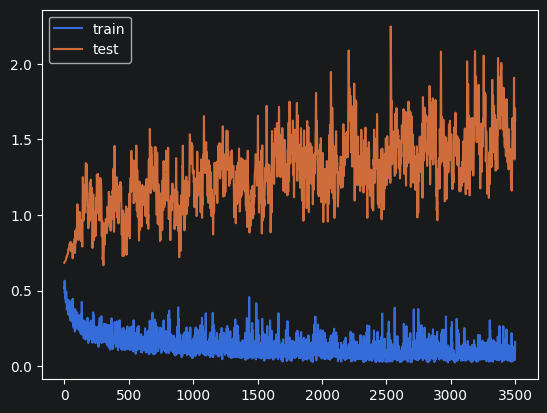

In [31]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

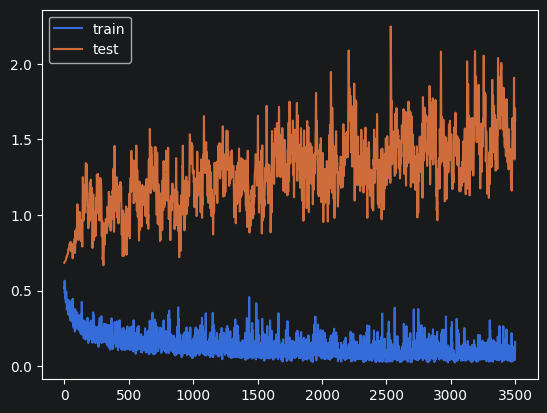